
# Kagome fRG sanity-check pipeline

This notebook builds a **standard spinful kagome model** using the corrected `channels.py` and `frg_flow.py`, then runs two benchmark interaction points inspired by the PRL phase diagram:

- **FM benchmark:** `U=6, V=0`
- **PI benchmark:** `U=0, V=10`

Target setup:
- no flux
- van Hove filling proxy: `mu = 0`
- `Npatch = 12`

The purpose is simple:

1. verify the corrected longitudinal channel construction in a full end-to-end pipeline  
2. check whether the final leading instability looks **FM-like** for large `U`  
3. check whether it looks **PI-like** for large `V`  

If the second case still does **not** show PI-like structure, the next place to inspect is likely:
- `form_factor.py`
- `kagome_order_diagnosis.py`

---


In [1]:

import sys
from pathlib import Path
from pprint import pprint
import numpy as np
import numpy as np
import matplotlib.pyplot as plt

# Make sure the uploaded modules are importable
sys.path.insert(0, "/mnt/data")

from noninteracting import KagomeNagaosa
from patching import FSPatcher, plot_patchset
from interaction import BareExtendedHubbard
from frg_flow import BareVertexFromInteraction, FRGFlowSolver
import sys
sys.path.insert(0, "/mnt/data")


## 1. Global parameters

You can tune the flow resolution here.

Notes:
- `mu=0` matches the PRL convention for kagome VHF.
- `band_index=1` is the dispersive band crossing `mu=0` inside each 3x3 spin block.
- `Npatch=12` is intentionally small, just for a fast pipeline sanity check.
- For a more reliable final physics check, increase `Npatch`, `nfreq`, and `n_steps`.


In [3]:

# ---------- noninteracting / patching ----------
MODEL_PARAMS = dict(t=1.0, phi=0.0)   # standard kagome = phi=0
MU = 0.0
NPATCH = 6
GRID_SIZE = 220
CONTOUR_MIN_POINTS = 40

# Each spin block is 3x3 inside the full 6x6 spinful Hamiltonian
UP_SLICE = slice(0, 3)
DN_SLICE = slice(3, 6)
LOCAL_BAND_INDEX = 1   # dispersive band crossing mu=0

# ---------- flow ----------
FLOW_KWARGS = dict(
    T_start=1,
    T_stop=0.001,
    n_steps=300,
    nfreq=10,
    diagnose_every=10,
    temperature_grid="log",
    include_explicit_T_prefactor=True,
    max_relative_update=1,
    min_substep_fraction=0.1,
    channel_divergence_threshold=1e4,
    eigenvalue_threshold=1e4,
    diagnosis_sort_by="abs",
    track_crossed_channel=True,
    diagnosis_Qs = [np.array([0.0, 0.0]), np.array([0.0,  np.pi/np.sqrt(3)]), np.array([ np.pi/2,  np.pi/(2*np.sqrt(3))]), np.array([-np.pi/2,  np.pi/(2*np.sqrt(3))])]
)


## 2. Build the standard spinful kagome model and the two spin patchsets

In [4]:
# ============================================================
# Manual exact-M patchsets: directly replace `patchsets`
# ============================================================

import numpy as np
from patching import PatchPoint, PatchSet

model = KagomeNagaosa(MODEL_PARAMS, spin=True, B=None)

def _sector_eig(model, k_cart, orbital_slice, band_index):
    kx, ky = float(k_cart[0]), float(k_cart[1])
    H = np.asarray(model.Hk(kx, ky), dtype=complex)
    Hs = H[orbital_slice, orbital_slice]
    evals, evecs = np.linalg.eigh(Hs)
    u = np.asarray(evecs[:, band_index], dtype=complex)
    u = u / np.linalg.norm(u)
    return float(evals[band_index]), u

def _orbital_weight(u):
    w = np.abs(np.asarray(u, dtype=complex))**2
    return w / np.sum(w)

def _cart_to_red(model, k):
    B = np.column_stack([np.asarray(model.b1, dtype=float),
                         np.asarray(model.b2, dtype=float)])
    return np.linalg.solve(B, np.asarray(k, dtype=float))

def _finite_diff_velocity(model, k_cart, orbital_slice, band_index, h=1e-6):
    kx, ky = float(k_cart[0]), float(k_cart[1])

    def band_energy(x, y):
        H = np.asarray(model.Hk(x, y), dtype=complex)
        Hs = H[orbital_slice, orbital_slice]
        evals, _ = np.linalg.eigh(Hs)
        return float(evals[band_index])

    vx = (band_energy(kx + h, ky) - band_energy(kx - h, ky)) / (2*h)
    vy = (band_energy(kx, ky + h) - band_energy(kx, ky - h)) / (2*h)
    return np.array([vx, vy], dtype=float)

def exact_M6_points(model):
    """
    直接手动写出 kagome/triangular reciprocal lattice 的 6 个 M 点
    就是你图上那个正六边形 contour 的六个角点。
    """
    b1 = np.asarray(model.b1, dtype=float)
    b2 = np.asarray(model.b2, dtype=float)

    # 3 inequivalent M points in reduced coordinates:
    # M1=(1/2,0), M2=(0,1/2), M3=(1/2,1/2)
    M1 = 0.5 * b1
    M2 = 0.5 * b2
    M3 = 0.5 * (b1 + b2)

    # ordered 6-point loop, matching your current patch contour style
    ks = np.array([
        -M1,      # left-upper / left-lower depending on b1,b2 convention
        -M3,
        -M2,
         M1,
         M3,
         M2,
    ], dtype=float)

    # reorder by polar angle to make a clean closed loop for fs_contour_k
    ang = np.arctan2(ks[:, 1], ks[:, 0])
    order = np.argsort(ang)
    return ks[order]

def _hex_bz_vertices_from_M6(M6):
    """
    给 plot_patchset 一个可视化用的六边形边界。
    这里直接用外接第一BZ六边形顶点的顺序近似即可，
    不影响后续 flow，只是为了兼容 plot_patchset。
    """
    return np.asarray(M6, dtype=float)

def build_exactM_patchset(model, orbital_slice, band_index):
    M6 = exact_M6_points(model)
    bz_vertices = _hex_bz_vertices_from_M6(M6)

    patches = []
    for pid, k in enumerate(M6):
        e, u = _sector_eig(model, k, orbital_slice, band_index)
        vF = _finite_diff_velocity(model, k, orbital_slice, band_index)

        patches.append(
            PatchPoint(
                patch_id=pid,
                k_cart=np.asarray(k, dtype=float),
                k_red=_cart_to_red(model, k),
                energy=e,
                vF=vF,
                vF_norm=float(np.linalg.norm(vF)),
                eigvec=u,
                orbital_weight=_orbital_weight(u),
            )
        )

    return PatchSet(
        mu=0.0,
        mu_used_for_contour=0.0,   # 这里严格固定为 0
        band_index=int(band_index),
        filling=np.nan,
        patches=patches,
        fs_contour_k=np.asarray(M6, dtype=float),
        bz_vertices=np.asarray(bz_vertices, dtype=float),
        b1=np.asarray(model.b1, dtype=float),
        b2=np.asarray(model.b2, dtype=float),
        gauge_method="manual_exact_M",
        gauge_loop_phase=0.0,
    )

# -------- directly replace original patchsets --------
patchsets = {
    "up": build_exactM_patchset(model, UP_SLICE, LOCAL_BAND_INDEX),
    "dn": build_exactM_patchset(model, DN_SLICE, LOCAL_BAND_INDEX),
}

print("Patch counts:", {k: v.Npatch for k, v in patchsets.items()})
print("mu used for contour (up/dn):", patchsets["up"].mu_used_for_contour, patchsets["dn"].mu_used_for_contour)
print("gauge method (up/dn):", patchsets["up"].gauge_method, patchsets["dn"].gauge_method)

for spin in ["up", "dn"]:
    print(f"\n===== {spin} exact-M patches =====")
    for p in patchsets[spin].patches:
        print(
            f"id={p.patch_id} | k={np.round(p.k_cart, 6)} | "
            f"E={p.energy:.10f} | w={np.round(p.orbital_weight, 6)} | "
            f"|vF|={p.vF_norm:.6e}"
        )

Patch counts: {'up': 6, 'dn': 6}
mu used for contour (up/dn): 0.0 0.0
gauge method (up/dn): manual_exact_M manual_exact_M

===== up exact-M patches =====
id=0 | k=[-1.570796 -0.9069  ] | E=0.0000000000 | w=[0. 1. 0.] | |vF|=3.682756e-16
id=1 | k=[-1.570796 -2.720699] | E=-0.0000000000 | w=[0. 0. 1.] | |vF|=2.449302e-16
id=2 | k=[-0.       -1.813799] | E=0.0000000000 | w=[1. 0. 0.] | |vF|=1.193415e-15
id=3 | k=[1.570796 0.9069  ] | E=0.0000000000 | w=[0. 1. 0.] | |vF|=3.682756e-16
id=4 | k=[1.570796 2.720699] | E=-0.0000000000 | w=[0. 0. 1.] | |vF|=2.449302e-16
id=5 | k=[0.       1.813799] | E=0.0000000000 | w=[1. 0. 0.] | |vF|=1.193415e-15

===== dn exact-M patches =====
id=0 | k=[-1.570796 -0.9069  ] | E=0.0000000000 | w=[0. 1. 0.] | |vF|=3.682756e-16
id=1 | k=[-1.570796 -2.720699] | E=-0.0000000000 | w=[0. 0. 1.] | |vF|=2.449302e-16
id=2 | k=[-0.       -1.813799] | E=0.0000000000 | w=[1. 0. 0.] | |vF|=1.193415e-15
id=3 | k=[1.570796 0.9069  ] | E=0.0000000000 | w=[0. 1. 0.] | |vF|=3.

## 3. Helpers for running a benchmark interaction point  Debug FRG Solver

In [5]:
from frg_flow import FRGFlowSolver

_old_step = FRGFlowSolver.step
_old_run = FRGFlowSolver.run

def _debug_step(self, T_old, dT):
    print(f"[DEBUG] entering step: T_old={T_old:.8f}, dT={dT:.8e}")
    try:
        rec = _old_step(self, T_old, dT)
        print(
            f"[DEBUG] leaving step: "
            f"T_new={getattr(rec, 'temperature', float(T_old + dT)):.8f}, "
            f"rhs_norm={getattr(rec, 'rhs_norm', None)}, "
            f"channel_norm={getattr(rec, 'channel_norm', None)}, "
            f"accepted_substeps={getattr(rec, 'accepted_substeps', None)}, "
            f"max_rel_update={getattr(rec, 'max_rel_update', None)}"
        )
        return rec
    except Exception as e:
        print(f"[DEBUG] exception in step:")
        print(f"        T_old = {T_old:.8f}")
        print(f"        dT    = {dT:.8e}")
        print(f"        T_new = {T_old + dT:.8f}")
        raise

def _debug_run(self):
    # print("[DEBUG] temperature path:")
    # for i, T in enumerate(self.temperature_path):
    #     print(f"  i={i:03d}, T={float(T):.8f}")
    return _old_run(self)

FRGFlowSolver.step = _debug_step
FRGFlowSolver.run = _debug_run

def build_solver(model, patchsets, U, V, flow_kwargs=None):
    flow_kwargs = {} if flow_kwargs is None else dict(flow_kwargs)
    interaction = BareExtendedHubbard.from_kagome_model(model, U=U, V=V)
    bare_gamma = BareVertexFromInteraction(interaction, patchsets)
    solver = FRGFlowSolver(
        patchsets=patchsets,
        bare_gamma=bare_gamma,
        **flow_kwargs,
    )
    return interaction, bare_gamma, solver


def summarize_history(history):
    rows = []
    for rec in history:
        rows.append({
            "step": rec.step_index,
            "T": rec.temperature,
            "channel_norm": rec.channel_norm,
            "rhs_norm": rec.rhs_norm,
            "leading_channel": rec.leading_channel_name,
            "leading_order": rec.leading_order_label,
            "leading_abs_eval": rec.leading_eigenvalue_abs,
            "instability": rec.instability,
            "reason": rec.instability_reason,
        })
    return rows


def pretty_print_final_record(history):
    rec = history[-1]
    print("===== Final record =====")
    pprint(rec.summary_dict())
    return rec


def plot_history(history, title):
    steps = [h.step_index for h in history]
    Ts = [h.temperature for h in history]
    evals = [np.nan if h.leading_eigenvalue_abs is None else h.leading_eigenvalue_abs for h in history]
    norms = [h.channel_norm for h in history]

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(steps, evals, marker="o")
    axes[0].set_xlabel("step")
    axes[0].set_ylabel("leading |eigenvalue|")
    axes[0].set_title(f"{title}: leading eigenvalue")

    axes[1].plot(steps, norms, marker="o")
    axes[1].set_xlabel("step")
    axes[1].set_ylabel("channel norm")
    axes[1].set_title(f"{title}: channel norm")

    plt.tight_layout()
    plt.show()


def run_case(case_name, U, V, flow_kwargs=None):
    print(f"\n===== Running case: {case_name} (U={U}, V={V}) =====")
    interaction, bare_gamma, solver = build_solver(
        model=model,
        patchsets=patchsets,
        U=U,
        V=V,
        flow_kwargs=flow_kwargs if flow_kwargs is not None else FLOW_KWARGS,
    )
    history = solver.run()
    print(f"history length = {len(history)}")
    print(f"instability record = {None if solver.instability_record is None else solver.instability_record.step_index}")
    final_rec = pretty_print_final_record(history)
    plot_history(history, case_name)
    return {
        "case_name": case_name,
        "U": U,
        "V": V,
        "interaction": interaction,
        "solver": solver,
        "history": history,
        "final_record": final_rec,
    }



## 4. FM benchmark: `U=6, V=0`

Expectation from the PRL benchmark at van Hove filling:
- dominant onsite interaction should favor **ferromagnetism (FM)**.



===== Running case: FM benchmark (U=6.0, V=0.0) =====
[DEBUG] entering step: T_old=1.00000000, dT=-2.28380327e-02
[DEBUG] leaving step: T_new=0.97716197, rhs_norm=35.304177761850895, channel_norm=0.8062779672443863, accepted_substeps=1, max_rel_update=0.13437966120739772
[DEBUG] entering step: T_old=0.97716197, dT=-2.23164570e-02
[DEBUG] leaving step: T_new=0.95484551, rhs_norm=36.97370661727648, channel_norm=1.6314001007810495, accepted_substeps=1, max_rel_update=0.13752035558944387
[DEBUG] entering step: T_old=0.95484551, dT=-2.18067930e-02
[DEBUG] leaving step: T_new=0.93303872, rhs_norm=38.72218722220606, channel_norm=2.475806822669963, accepted_substeps=1, max_rel_update=0.1407344536481523
[DEBUG] entering step: T_old=0.93303872, dT=-2.13087688e-02
[DEBUG] leaving step: T_new=0.91172995, rhs_norm=40.55335319210218, channel_norm=3.3399488484268125, accepted_substeps=1, max_rel_update=0.1440236709594749
[DEBUG] entering step: T_old=0.91172995, dT=-2.08221184e-02
[DEBUG] leaving ste

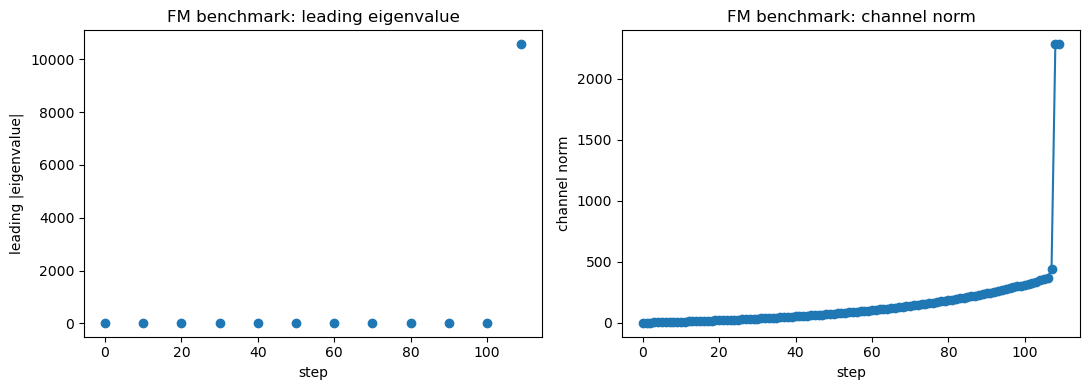

In [6]:

fm_result = run_case("FM benchmark", U=6.0, V=.0, flow_kwargs=FLOW_KWARGS)


===== Final-state diagnosis across all Q =====

===== Q[0] = [15.70796327 12.69659555] =====
pp_singlet_sz0             |eig|max = 10567.661
pp_triplet_sz0             |eig|max = 4.4030723e-13
ph_charge_longitudinal     |eig|max = 2874.8572
ph_spin_longitudinal       |eig|max = 3637.1026
--> leading channel at this Q: pp_singlet_sz0  (|eig|max = 10567.661)

===== Q[1] = [15.70796327 14.51039491] =====
pp_singlet_sz0             |eig|max = 1453.0478
pp_triplet_sz0             |eig|max = 1453.0478
ph_charge_longitudinal     |eig|max = 2906.0956
ph_spin_longitudinal       |eig|max = 1453.0478
--> leading channel at this Q: ph_charge_longitudinal  (|eig|max = 2906.0956)

===== Q[2] = [17.27875959 13.60349523] =====
pp_singlet_sz0             |eig|max = 1741.9086
pp_triplet_sz0             |eig|max = 1741.9086
ph_charge_longitudinal     |eig|max = 3483.8173
ph_spin_longitudinal       |eig|max = 1741.9086
--> leading channel at this Q: ph_charge_longitudinal  (|eig|max = 3483.8173)

===== Q[

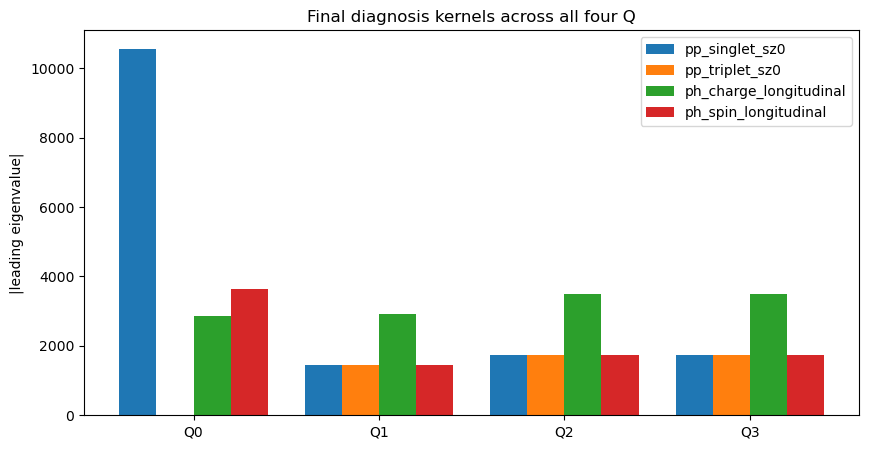


==== pp_singlet_sz0 ====
Q = [0. 0.]
|eig|max = 10567.660510053047
vec.real = [0.40393056 0.40393056 0.41674956 0.40393056 0.40393056 0.41674956]
vec.abs  = [0.40393056 0.40393056 0.41674956 0.40393056 0.40393056 0.41674956]

==== pp_triplet_sz0 ====
Q = [0. 0.]
|eig|max = 4.403072291788038e-13
vec.real = [-4.62175032e-16  5.00000000e-01 -2.50000000e-01 -3.84943547e-16
  5.00000000e-01 -2.50000000e-01]
vec.abs  = [0.38729833 0.5        0.31622777 0.38729833 0.5        0.31622777]

==== ph_charge_longitudinal ====
Q = [0. 0.]
|eig|max = 2874.857153053586
vec.real = [-0.3088925  -0.3088925   0.55603134 -0.3088925  -0.3088925   0.55603134]
vec.abs  = [0.3088925  0.3088925  0.55603134 0.3088925  0.3088925  0.55603134]

==== ph_spin_longitudinal ====
Q = [0. 0.]
|eig|max = 3637.1026081063947
vec.real = [0.40730595 0.40730595 0.41012647 0.40730595 0.40730595 0.41012647]
vec.abs  = [0.40730595 0.40730595 0.41012647 0.40730595 0.40730595 0.41012647]


In [9]:
# 你现在 flow_kwargs 里已经有 diagnosis_Qs
Qs_to_check = FLOW_KWARGS["diagnosis_Qs"] + 5*np.array([np.pi, np.pi/np.sqrt(3)]) +np.array([0,2*np.pi/np.sqrt(3)])
# Qs_to_check = FLOW_KWARGS["diagnosis_Qs"] 
channels_to_check = [
    "pp_singlet_sz0",
    "pp_triplet_sz0",
    "ph_charge_longitudinal",
    "ph_spin_longitudinal",
]
solver = fm_result["solver"]
print("===== Final-state diagnosis across all Q =====")
for i, Q in enumerate(Qs_to_check):
    Q = np.asarray(Q, dtype=float)
    kernels = solver.build_diagnosis_kernel_dict(Q)

    print(f"\n===== Q[{i}] = {Q} =====")
    vals_dict = {}

    for name in channels_to_check:
        k = kernels[name]
        vals, vecs = k.eig(sort_by="abs")
        eigmax = abs(vals[0])
        vals_dict[name] = eigmax
        print(f"{name:26s} |eig|max = {eigmax:.8g}")

    lead_name = max(vals_dict, key=vals_dict.get)
    print(f"--> leading channel at this Q: {lead_name}  (|eig|max = {vals_dict[lead_name]:.8g})")
Q_summary = []

for i, Q in enumerate(Qs_to_check):
    Q = np.asarray(Q, dtype=float)
    kernels = solver.build_diagnosis_kernel_dict(Q)

    row = {
        "Q_index": i,
        "Q_vec": Q,
    }

    for name in channels_to_check:
        vals, _ = kernels[name].eig(sort_by="abs")
        row[name] = float(abs(vals[0]))

    row["leading_channel"] = max(channels_to_check, key=lambda name: row[name])
    row["leading_value"] = row[row["leading_channel"]]
    Q_summary.append(row)

Q_summary

import matplotlib.pyplot as plt
import numpy as np

labels = [f"Q{i}" for i in range(len(Q_summary))]
x = np.arange(len(labels))
width = 0.2

pp_s = [row["pp_singlet_sz0"] for row in Q_summary]
pp_t = [row["pp_triplet_sz0"] for row in Q_summary]
ph_c = [row["ph_charge_longitudinal"] for row in Q_summary]
ph_s = [row["ph_spin_longitudinal"] for row in Q_summary]

plt.figure(figsize=(10, 5))
plt.bar(x - 1.5*width, pp_s, width, label="pp_singlet_sz0")
plt.bar(x - 0.5*width, pp_t, width, label="pp_triplet_sz0")
plt.bar(x + 0.5*width, ph_c, width, label="ph_charge_longitudinal")
plt.bar(x + 1.5*width, ph_s, width, label="ph_spin_longitudinal")

plt.xticks(x, labels)
plt.ylabel("|leading eigenvalue|")
plt.title("Final diagnosis kernels across all four Q")
plt.legend()
plt.show()
# solver = fm_result["solver"]
Q = np.array([0.0, 0.0])
kernels = solver.build_diagnosis_kernel_dict(Q)
# for name, k in kernels.items():
#     vals, vecs = k.eig(sort_by="abs")
#     print(f"{name:25s}  |eig|max = {abs(vals[0]):.6g}")

for name in ["pp_singlet_sz0", "pp_triplet_sz0", "ph_charge_longitudinal", "ph_spin_longitudinal"]:
    k = kernels[name]
    vals, vecs = k.eig(sort_by="abs")
    print(f"\n==== {name} ====")
    print("Q =", k.Q)
    print("|eig|max =", abs(vals[0]))
    print("vec.real =", np.real(vecs[:, 0]))
    print("vec.abs  =", np.abs(vecs[:, 0]))


## 5. PI benchmark: `U=0, V=10`

Expectation from the PRL benchmark at van Hove filling:
- dominant nearest-neighbor repulsion should favor **Pomeranchuk instability (PI)** with d-wave character.

If this still does **not** look PI-like, then the likely next suspects are:
- `form_factor.py`
- `kagome_order_diagnosis.py`



===== Running case: PI benchmark (U=6.0, V=6.0) =====
[DEBUG] entering step: T_old=1.00000000, dT=-2.28380327e-02
[DEBUG] leaving step: T_new=0.97716197, rhs_norm=141.21671104740358, channel_norm=3.225111868977545, accepted_substeps=1, max_rel_update=0.26875932241479544
[DEBUG] entering step: T_old=0.97716197, dT=-2.23164570e-02
[DEBUG] leaving step: T_new=0.95484551, rhs_norm=128.0207697938606, channel_norm=6.08208187208667, accepted_substeps=1, max_rel_update=0.23808083359242713
[DEBUG] entering step: T_old=0.95484551, dT=-2.18067930e-02
[DEBUG] leaving step: T_new=0.93303872, rhs_norm=163.44950876644523, channel_norm=8.784707319000846, accepted_substeps=1, max_rel_update=0.29702580052235533
[DEBUG] entering step: T_old=0.93303872, dT=-2.13087688e-02
[DEBUG] leaving step: T_new=0.91172995, rhs_norm=263.2337883911358, channel_norm=13.161175401905165, accepted_substeps=1, max_rel_update=0.467432327298207
[DEBUG] entering step: T_old=0.91172995, dT=-2.08221184e-02
[DEBUG] leaving step:

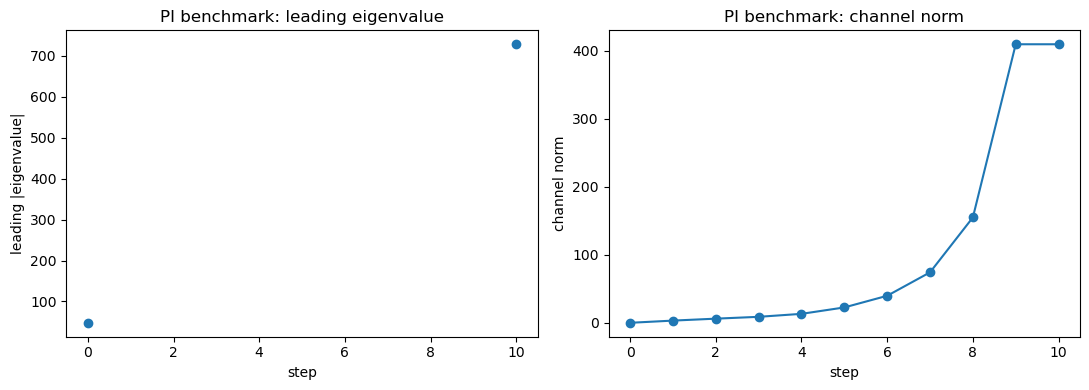

In [13]:

pi_result = run_case("PI benchmark", U=6.0, V=6.0, flow_kwargs=FLOW_KWARGS)



==== pp_singlet_sz0 ====
Q = [0. 0.]
|eig|max = 727.9020482931903
vec.real = [-3.02612853e-18  6.23805257e-01 -3.32966967e-01 -3.02612853e-18
  6.23805257e-01 -3.32966967e-01]
vec.abs  = [3.02612853e-18 6.23805257e-01 3.32966967e-01 3.02612853e-18
 6.23805257e-01 3.32966967e-01]

==== pp_triplet_sz0 ====
Q = [0. 0.]
|eig|max = 5.684341886080803e-14
vec.real = [ 1.53347698e-03  7.31102564e-58  7.07104287e-01  1.53347698e-03
 -1.53347695e-03  7.07104287e-01]
vec.abs  = [1.53347698e-03 3.54688219e-37 7.07104287e-01 1.53347698e-03
 1.53347695e-03 7.07104287e-01]

==== ph_charge_longitudinal ====
Q = [0. 0.]
|eig|max = 470.212026237415
vec.real = [0.40824829 0.40824829 0.40824829 0.40824829 0.40824829 0.40824829]
vec.abs  = [0.40824829 0.40824829 0.40824829 0.40824829 0.40824829 0.40824829]

==== ph_spin_longitudinal ====
Q = [0. 0.]
|eig|max = 417.0815251920056
vec.real = [-0.49542026 -0.00903698  0.50445723 -0.49542026 -0.00903698  0.50445723]
vec.abs  = [0.49542026 0.00903698 0.50445723

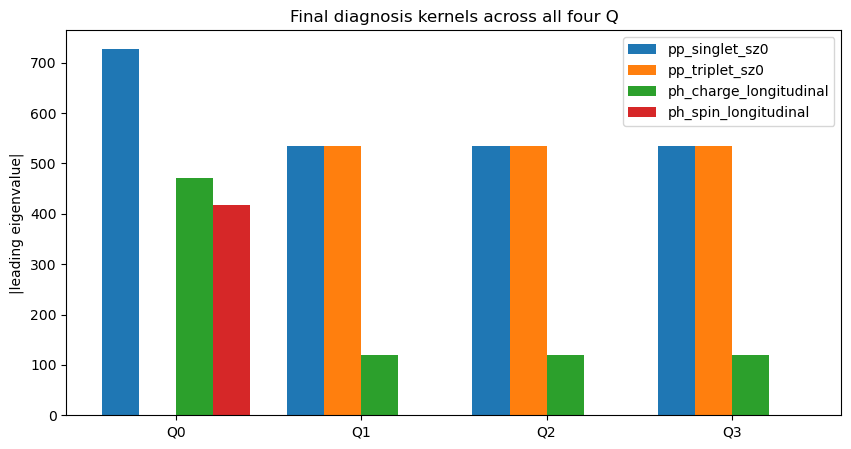


==== pp_singlet_sz0 ====
Q = [0. 0.]
|eig|max = 727.9020482931903
vec.real = [-3.02612853e-18  6.23805257e-01 -3.32966967e-01 -3.02612853e-18
  6.23805257e-01 -3.32966967e-01]
vec.abs  = [3.02612853e-18 6.23805257e-01 3.32966967e-01 3.02612853e-18
 6.23805257e-01 3.32966967e-01]

==== pp_triplet_sz0 ====
Q = [0. 0.]
|eig|max = 5.684341886080803e-14
vec.real = [ 1.53347698e-03  7.31102564e-58  7.07104287e-01  1.53347698e-03
 -1.53347695e-03  7.07104287e-01]
vec.abs  = [1.53347698e-03 3.54688219e-37 7.07104287e-01 1.53347698e-03
 1.53347695e-03 7.07104287e-01]

==== ph_charge_longitudinal ====
Q = [0. 0.]
|eig|max = 470.212026237415
vec.real = [0.40824829 0.40824829 0.40824829 0.40824829 0.40824829 0.40824829]
vec.abs  = [0.40824829 0.40824829 0.40824829 0.40824829 0.40824829 0.40824829]

==== ph_spin_longitudinal ====
Q = [0. 0.]
|eig|max = 417.0815251920056
vec.real = [-0.49542026 -0.00903698  0.50445723 -0.49542026 -0.00903698  0.50445723]
vec.abs  = [0.49542026 0.00903698 0.50445723

In [14]:

solver = pi_result["solver"]
Q = np.array([0.0, 0.0])
kernels = solver.build_diagnosis_kernel_dict(Q)
# for name, k in kernels.items():
#     vals, vecs = k.eig(sort_by="abs")
#     print(f"{name:25s}  |eig|max = {abs(vals[0]):.6g}")

for name in ["pp_singlet_sz0", "pp_triplet_sz0", "ph_charge_longitudinal", "ph_spin_longitudinal"]:
    k = kernels[name]
    vals, vecs = k.eig(sort_by="abs")
    print(f"\n==== {name} ====")
    print("Q =", k.Q)
    print("|eig|max =", abs(vals[0]))
    print("vec.real =", np.real(vecs[:, 0]))
    print("vec.abs  =", np.abs(vecs[:, 0]))

# 你现在 flow_kwargs 里已经有 diagnosis_Qs
Qs_to_check = FLOW_KWARGS["diagnosis_Qs"] + 1*np.array([np.pi, np.pi/np.sqrt(3)]) +np.array([0,2*np.pi/np.sqrt(3)])

channels_to_check = [
    "pp_singlet_sz0",
    "pp_triplet_sz0",
    "ph_charge_longitudinal",
    "ph_spin_longitudinal",
]
solver = pi_result["solver"]
print("===== Final-state diagnosis across all Q =====")
for i, Q in enumerate(Qs_to_check):
    Q = np.asarray(Q, dtype=float)
    kernels = solver.build_diagnosis_kernel_dict(Q)

    print(f"\n===== Q[{i}] = {Q} =====")
    vals_dict = {}

    for name in channels_to_check:
        k = kernels[name]
        vals, vecs = k.eig(sort_by="abs")
        eigmax = abs(vals[0])
        vals_dict[name] = eigmax
        print(f"{name:26s} |eig|max = {eigmax:.8g}")

    lead_name = max(vals_dict, key=vals_dict.get)
    print(f"--> leading channel at this Q: {lead_name}  (|eig|max = {vals_dict[lead_name]:.8g})")
Q_summary = []

for i, Q in enumerate(Qs_to_check):
    Q = np.asarray(Q, dtype=float)
    kernels = solver.build_diagnosis_kernel_dict(Q)

    row = {
        "Q_index": i,
        "Q_vec": Q,
    }

    for name in channels_to_check:
        vals, _ = kernels[name].eig(sort_by="abs")
        row[name] = float(abs(vals[0]))

    row["leading_channel"] = max(channels_to_check, key=lambda name: row[name])
    row["leading_value"] = row[row["leading_channel"]]
    Q_summary.append(row)

Q_summary

import matplotlib.pyplot as plt
import numpy as np

labels = [f"Q{i}" for i in range(len(Q_summary))]
x = np.arange(len(labels))
width = 0.2

pp_s = [row["pp_singlet_sz0"] for row in Q_summary]
pp_t = [row["pp_triplet_sz0"] for row in Q_summary]
ph_c = [row["ph_charge_longitudinal"] for row in Q_summary]
ph_s = [row["ph_spin_longitudinal"] for row in Q_summary]

plt.figure(figsize=(10, 5))
plt.bar(x - 1.5*width, pp_s, width, label="pp_singlet_sz0")
plt.bar(x - 0.5*width, pp_t, width, label="pp_triplet_sz0")
plt.bar(x + 0.5*width, ph_c, width, label="ph_charge_longitudinal")
plt.bar(x + 1.5*width, ph_s, width, label="ph_spin_longitudinal")

plt.xticks(x, labels)
plt.ylabel("|leading eigenvalue|")
plt.title("Final diagnosis kernels across all four Q")
plt.legend()
plt.show()
# solver = fm_result["solver"]
Q = np.array([0.0, 0.0])
kernels = solver.build_diagnosis_kernel_dict(Q)
# for name, k in kernels.items():
#     vals, vecs = k.eig(sort_by="abs")
#     print(f"{name:25s}  |eig|max = {abs(vals[0]):.6g}")

for name in ["pp_singlet_sz0", "pp_triplet_sz0", "ph_charge_longitudinal", "ph_spin_longitudinal"]:
    k = kernels[name]
    vals, vecs = k.eig(sort_by="abs")
    print(f"\n==== {name} ====")
    print("Q =", k.Q)
    print("|eig|max =", abs(vals[0]))
    print("vec.real =", np.real(vecs[:, 0]))
    print("vec.abs  =", np.abs(vecs[:, 0]))

## 6. Compact side-by-side summary

In [ ]:

def compact_case_summary(result):
    rec = result["final_record"]
    return {
        "case": result["case_name"],
        "U": result["U"],
        "V": result["V"],
        "leading_channel": rec.leading_channel_name,
        "leading_order": rec.leading_order_label,
        "leading_abs_eval": rec.leading_eigenvalue_abs,
        "channel_norm": rec.channel_norm,
        "instability": rec.instability,
        "instability_reason": rec.instability_reason,
    }

summary = [
    compact_case_summary(fm_result),
    compact_case_summary(pi_result),
]

for row in summary:
    pprint(row)



## 7. Optional: inspect the raw diagnosis payloads

This is useful when:
- the FM case is reasonable but the PI case is not
- or the final `leading_order_label` is too coarse / ambiguous


In [ ]:

print("===== FM diagnosis payload =====")
pprint(fm_result["final_record"].diagnosis_payload)

print("\n===== PI diagnosis payload =====")
pprint(pi_result["final_record"].diagnosis_payload)



## 8. What to conclude from the outcomes

### If you get:
- `U=6, V=0` → FM-like
- `U=0, V=10` → PI-like

then the corrected `channels.py` + `frg_flow.py` have likely fixed the main bug, and the whole pipeline is much closer to the target PRL behavior.

### If you get:
- FM benchmark looks reasonable
- PI benchmark still does **not** become PI-like

then the next things to debug are likely:
1. **form-factor projection**
2. **PI degeneracy handling**
3. **kagome-specific diagnosis templates**

and only after that would I go back and seriously suspect the one-loop kernel again.
